# Validation
This workbook creates an instance of the proposed model and performs a range of validation tests.

In [50]:
import os; os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' # To filter TensorFlow warnings for a cleaner log
from warnings import filterwarnings; filterwarnings('ignore') # To filter warnings for a cleaner log
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.patheffects as patheffects
from cycler import cycler
from data import get_data_for_model, undersample, train_test_split
from p_h_vae import poincare_hierarchical_vae
from poincare import exp_map_0, exp_map, lambda_, GyroplaneLayer
from ffnn import ffnn
from nn import two_stage_nn

### User Inputs

In [51]:
# Location of the datasets
data_location = '../Updated_NGA_West2_Flatfile_RotD50_d005_public_version.xlsx'
IM_first3secs_data_filepath = '../First3secs_IMs.csv'

# Location to save and read model outputs
data_dir = 'FINAL RESULTS'

# Optional suffix for all model outputs
file_sfx = 'Run_25'

# Boolean flag to indicate whether a new model should be trained for validation
retrain = False

# Defining the regularisation features
event_feats, sample_feats = ['Earthquake Magnitude', 'Hypocenter Depth (km)'], ['ClstD (km)', 'Vs30 (m/s) selected for analysis']

## Training

### Reading and Pre-processing Data
This cell is only ran if ```retrain=True```.

In [52]:
if retrain:
    # Reading and pre-processing the data
    spectrum, data = get_data_for_model(data_location, [[0.02, 1.5, 0.02], [1.5, 2.5, 0.1], [2.5, 5.5, 0.5]]) # 91 periods
        
    filt = (data['Hypocenter Depth (km)'] < 21) & (data['ClstD (km)'] < 300) & (data['Vs30 (m/s) selected for analysis'] < 750)
    print(f'Original: {spectrum.shape}, # events: {len(data["EQID"].unique())}')
    spectrum, data = spectrum[filt], data[filt]
    print(f'Filtered: {spectrum.shape}, # events: {len(data["EQID"].unique())}')
    spectrum, data = undersample(spectrum, data, [*event_feats, *sample_feats], 0.8)
    print(f'Undersampled: {spectrum.shape}, # events: {len(data["EQID"].unique())}')

    # Train-test split
    spectrum_train, spectrum_test, data_train, data_test = train_test_split(spectrum, data, 0.2)

### Training the Model
A ```while``` loop is used just in case the negative KL-divergence issue is encountered (see Appendix C). This cell is only ran if ```retrain=True```.

In [53]:
if retrain:
    # Creating and training the model
    model = poincare_hierarchical_vae((len(spectrum.columns), ), 2, 1.0, rec_weight=30.0, kl_weight=1.0, reg_weight=50.0, kl_hyp_weight=1000.0, reg_hyp_weight=10000.0, grp_var=0.1, s=2.0)
    loss, loss_v = model.train(spectrum_train, data_train, sample_feats, event_feats, 300, 500)

    # In case of negative KL-divergence (see Appendix B)
    while loss[-1, 1] < 0.0:
        print('Negative KL-divergence issue (see Appendix B) - re-initialising and training')
        model = poincare_hierarchical_vae((len(spectrum.columns), ), 2, 1.0, rec_weight=30.0, kl_weight=1.0, reg_weight=50.0, kl_hyp_weight=1000.0, reg_hyp_weight=10000.0, grp_var=0.1, s=2.0)
        loss, loss_v = model.train(spectrum_train, data_train, sample_feats, event_feats, 300, 500)

    # Processing the full dataset
    latent_embedding = model.encoder(spectrum.to_numpy(), training=False)
    mu, ln_sigma2 = np.split(latent_embedding.numpy(), indices_or_sections=2, axis=1)
    ln_sigma2 = np.clip(ln_sigma2, -10, 10)
    mu = exp_map_0(mu, model.c)
    z = model.reparam(mu, ln_sigma2).numpy()
    spectrum_ = model.decoder(z, training=False).numpy()

    if data_dir == '': data_dir = '.'
    # Saving the model and outputs
    np.save(f'{data_dir}/Train loss {file_sfx}.npy', loss)
    np.save(f'{data_dir}/Val loss {file_sfx}.npy', loss_v)
    np.save(f'{data_dir}/Embeddings {file_sfx}.npy', latent_embedding)
    np.save(f'{data_dir}/Means {file_sfx}.npy', exp_map_0(model.group_means))
    np.save(f'{data_dir}/Pred spectrum {file_sfx}.npy', spectrum_)
    np.save(f'{data_dir}/Train EQIDs {file_sfx}.npy', data_train['EQID'].unique())
    spectrum.to_csv(f'{data_dir}/Spectrum {file_sfx}.csv', index=False)
    data.to_csv(f'{data_dir}/Data {file_sfx}.csv', index=False)
    model.decoder.save(f'{data_dir}/Decoder {file_sfx}.keras')
    model.encoder.save(f'{data_dir}/Encoder {file_sfx}.keras')
    np.save(f'{data_dir}/Model c {file_sfx}.npy', np.array(model.c, np.float32))

### Reading Model Outputs

In [54]:
loss = np.load(f'{data_dir}/Train loss {file_sfx}.npy')
loss_v = np.load(f'{data_dir}/Val loss {file_sfx}.npy')
latent_embedding = np.load(f'{data_dir}/Embeddings {file_sfx}.npy')
group_means = np.load(f'{data_dir}/Means {file_sfx}.npy')
spectrum_ = np.load(f'{data_dir}/Pred spectrum {file_sfx}.npy')
train_eqids = np.load(f'{data_dir}/Train EQIDs {file_sfx}.npy')
spectrum = pd.read_csv(f'{data_dir}/Spectrum {file_sfx}.csv')
data = pd.read_csv(f'{data_dir}/Data {file_sfx}.csv')
decoder = tf.keras.models.load_model(f'{data_dir}/Decoder {file_sfx}.keras', custom_objects={'GyroplaneLayer': GyroplaneLayer})
encoder = tf.keras.models.load_model(f'{data_dir}/Encoder {file_sfx}.keras')
model_c = np.load(f'{data_dir}/Model c {file_sfx}.npy')

mu_z, ln_var_z = np.split(latent_embedding, indices_or_sections=2, axis=1)
mu_z = exp_map_0(mu_z.astype(np.float32), model_c).numpy()
eps = np.random.normal(size=mu_z.shape)
z = (np.exp(ln_var_z) ** 0.5) * eps
z = exp_map(mu_z.astype(np.float32), z.astype(np.float32) / lambda_(mu_z.astype(np.float32), model_c), model_c).numpy()

In [55]:
spectrum_train, data_train = spectrum[data['EQID'].isin(train_eqids)], data[data['EQID'].isin(train_eqids)]
spectrum_test, data_test = spectrum[~data['EQID'].isin(train_eqids)], data[~data['EQID'].isin(train_eqids)]

# Zero indexing EQIDs so that these can be comapred to the group means if desired. 
eqids = data['EQID'].unique()
data.loc[:, 'EQID'] = data['EQID'].apply(lambda x: np.where(eqids == x)[0][0])
data_train.loc[:, 'EQID'] = data_train['EQID'].apply(lambda x: np.where(eqids == x)[0][0])
data_test.loc[:, 'EQID'] = data_test['EQID'].apply(lambda x: np.where(eqids == x)[0][0])

# Getting spectral periods into a list.
T = [float(c[1:-1]) if c != 'PGA (g)' else 0.0 for c in spectrum.columns]

## Validation

### Plotting Functions and Parameters

In [56]:
plt.rcParams.update({
    'axes.prop_cycle': cycler('color', plt.get_cmap('Set2').colors),
    'image.cmap': 'terrain'
})

def add_cbar(ax, field, label, cmap='terrain', ticks=None):
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size="5%", pad=0.05)
    sm = cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(vmin=min(field), vmax=max(field)))
    sm.set_array([])
    cb = ax.figure.colorbar(sm, cax=cax)
    cb.set_label(label, size=12)
    if ticks is not None:
        cb.set_ticks(ticks)

def add_letter_label(ax, letter, pos=[0.1, 0.9], fontsize=11):
    ax.text(*pos, letter, transform=ax.transAxes, ha='center', va='center', fontsize=fontsize, fontweight='bold')

### Performance Metrics

In [57]:
def R_squared(real_data, recon_data):
    """
    This function computes the R squared metric for a given model and dataset.

    Args:
        model (custom VAE class): The model to be tested.
        real_data (pandas dataframe): The data to be put through the model and reconstructed.

    Returns:
        numpy array: The R squared values for every feature in the model.
    """
    if type(real_data) is not np.ndarray: real_data = real_data.to_numpy()

    r2_scores = []
    for i in range(real_data.shape[1]):  # Loop through periods
        r2 = r2_score(real_data[:, i], recon_data[:, i])
        r2_scores.append(r2)
    return np.array(r2_scores)

def index_of_agreement(real_data, recon_data):
    """
    This function computes the pairwise index of agremment for each sample in the provided dataset.
    """
    if type(real_data) is not np.ndarray: real_data = real_data.to_numpy()

    obs_mean = np.tile(np.mean(real_data, axis=1)[:, None], [1, real_data.shape[1]])
    numerator = np.sum((recon_data - real_data) ** 2.0, axis=1)
    denominator = np.sum((np.abs(recon_data - obs_mean) + np.abs(real_data - obs_mean)) ** 2.0, axis=1)
    return 1.0 - numerator / denominator

### Reconstruction Figure
This contains computation of IoA and $R^2$, the reconstruction of two example spectra, and analysis of cross-correlations between spectral periods.

Training R^2: 0.9691866735624631
Testing R^2: 0.9667257305684146
All data R^2: 0.9687744460109367
Cross-correlation worst between periods 0.06 and 5.0 with -0.044947296380996704


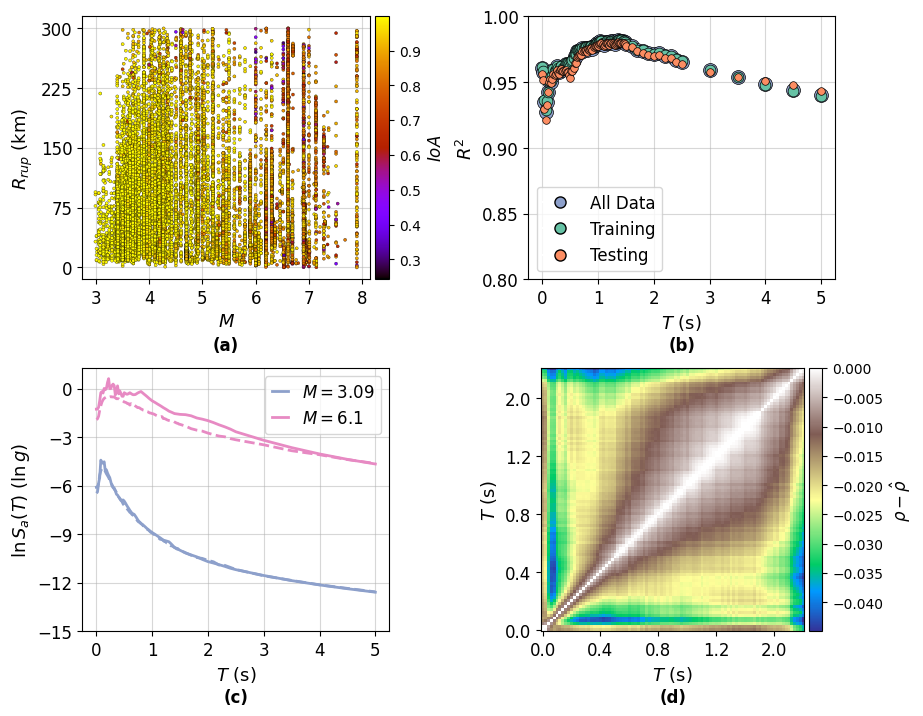

In [58]:
fig, ax = plt.subplots(2, 2, figsize=(9, 7.2), tight_layout=True)
fig.subplots_adjust(hspace=0.3)

# Index of agreement subplot
data['err'] =  index_of_agreement(spectrum.to_numpy(), spectrum_)

ax[0][0].scatter(data['Earthquake Magnitude'], data['ClstD (km)'], s=5, c=data['err'], zorder=2, edgecolor='black', linewidth=0.2, cmap='gnuplot')

add_cbar(ax[0][0], data['err'], r'$IoA$', 'gnuplot')
ax[0][0].set_xticks([3, 4, 5, 6, 7, 8])
ax[0][0].set_yticks([0, 75, 150, 225, 300])

ax[0][0].grid(zorder=0, alpha=0.5)
ax[0][0].set_xlabel(r'$M$', fontsize=13)
ax[0][0].set_ylabel(r'$R_{rup}$ (km)', fontsize=13)
add_letter_label(ax[0][0], '(a)', pos=[0.5, -0.25], fontsize=12)
# --

# R^2 subplot
R2 = R_squared(spectrum_train, recon_data=spectrum_[data_train.index])
print(f'Training R^2: {R2.mean()}')
p_tr = ax[0][1].scatter(T, R2, zorder=3, label='Training', s=60, edgecolor='black', linewidth=0.5)

R2 = R_squared(spectrum_test, recon_data=spectrum_[data_test.index])
print(f'Testing R^2: {R2.mean()}')
p_te = ax[0][1].scatter(T, R2, zorder=4, label='Testing', s=30, edgecolor='black', linewidth=0.5)

R2 = R_squared(spectrum, recon_data=spectrum_)
print(f'All data R^2: {R2.mean()}')
p_al = ax[0][1].scatter(T, R2, zorder=2, label='All Data', s=100, edgecolor='black', linewidth=0.5)

ax[0][1].grid(zorder=0, alpha=0.5)
ax[0][1].set_xlabel(r'$T$ (s)', fontsize=13)
ax[0][1].set_ylabel(r'$R^2$', fontsize=13)
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='All Data', markerfacecolor=p_al.get_facecolor(), markeredgecolor='black', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Training', markerfacecolor=p_tr.get_facecolor(), markeredgecolor='black', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Testing', markerfacecolor=p_te.get_facecolor(), markeredgecolor='black', markersize=8)
]
ax[0][1].set_yticks([0.8, 0.85, 0.9, 0.95, 1.0])
ax[0][1].legend(handles=legend_elements, fontsize=12)
add_letter_label(ax[0][1], '(b)', pos=[0.5, -0.25], fontsize=12)
# --

# Example reconstruction subplot
err_sorted = np.sort(data['err'].to_numpy())[::-1]

ix1, ix2 = np.where(data['err'] == err_sorted[0])[0][0], np.where(data['Earthquake Magnitude'] > 6)[0][0]
ax[1][0].plot([], []); ax[1][0].plot([], []) # Skipping two colours
p = ax[1][0].plot(T, spectrum.iloc[ix1], label=r'$M=$'+str(data.iloc[ix1]['Earthquake Magnitude']), linewidth=2)
ax[1][0].plot(T, spectrum_[ix1], color=p[0].get_color(), linestyle='dashed', linewidth=2)
p = ax[1][0].plot(T, spectrum.iloc[ix2], label=r'$M=$'+str(data.iloc[ix2]['Earthquake Magnitude']), linewidth=2)
ax[1][0].plot(T, spectrum_[ix2], color=p[0].get_color(), linestyle='dashed', linewidth=2)

ax[1][0].grid(alpha=0.5)
ax[1][0].set_xlabel(r'$T$ (s)', fontsize=13)
ax[1][0].set_ylabel(r'$\ln{S_a(T)}$ ($\ln{g}$)', fontsize=13)
ax[1][0].legend(fontsize=12, handlelength=1)
ax[1][0].set_yticks([-15, -12, -9, -6, -3, 0])
add_letter_label(ax[1][0], '(c)', pos=[0.5, -0.25], fontsize=12)
# --

# Cross-correlation subplot
S_true = spectrum.to_numpy()
M = np.zeros((spectrum_.shape[1], spectrum_.shape[1]), dtype=np.float32)
for x in range(spectrum_.shape[1]):
    for y in range(spectrum_.shape[1]):
        r_true = pearsonr(S_true[:, x], S_true[:, y])
        r_pred = pearsonr(spectrum_[:, x], spectrum_[:, y])
        M[x, y] = r_true.statistic - r_pred.statistic

ax[1][1].matshow(M, origin='lower')
ax[1][1].set_xlabel(r'$T$ (s)', fontsize=13)
ax[1][1].set_ylabel(r'$T$ (s)', fontsize=13)
ax[1][1].set_xticks([0, 20, 40, 60, 80], [T[0], T[20], T[40], T[60], T[80]])
ax[1][1].tick_params(axis='x', which='both', top=False, labeltop=False, bottom=True, labelbottom=True)
ax[1][1].set_yticks([0, 20, 40, 60, 80], [T[0], T[20], T[40], T[60], T[80]])
add_cbar(ax[1][1], M.flatten(), r'$\rho - \hat{\rho}$')
add_letter_label(ax[1][1], '(d)', pos=[0.5, -0.25], fontsize=12)
min_index_flat = np.argmin(M)
mn = np.unravel_index(min_index_flat, M.shape)
print(f'Cross-correlation worst between periods {T[mn[0]]} and {T[mn[1]]} with {M.min()}')
# --

for a in ax:
    for ax_ in a:
        ax_.tick_params(axis='both', labelsize=12)

plt.savefig(f'{data_dir}/IoA R2 examples and cross-corr {file_sfx}.png', bbox_inches='tight', dpi=400)

### Residuals Figure
This contains computation of residuals between true and reconstructed spectra, arranged by $M$ and $R_{\mathrm{rup}}$ for three chosen periods.

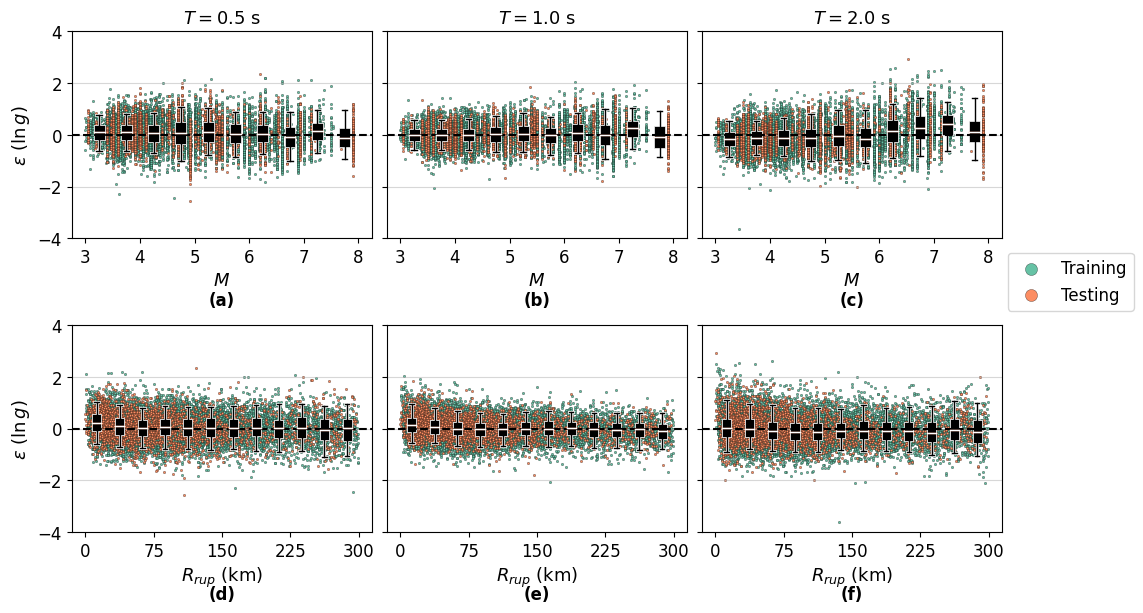

In [59]:
fig, ax = plt.subplots(2, 3, figsize=(12, 6.5), sharey=True)
ax[0][0].set_ylim(-4, 4)
fig.subplots_adjust(wspace=0.05, hspace=0.42)
for a in ax:
    for ax_ in a:
        next(ax_._get_lines.prop_cycler)
        ax_.tick_params(axis='both', labelsize=12)

# Looping through each period under analysis
letters = 'adbecf'
for i, t in enumerate([0.5, 1.0, 2.0]):
    # Residual computations
    res_train = spectrum_train[f'T{t}0S'] - spectrum_[data_train.index, np.where(np.array(T) == t)[0][0]]
    res_test = spectrum_test[f'T{t}0S'] - spectrum_[data_test.index, np.where(np.array(T) == t)[0][0]]
    res_all = spectrum[f'T{t}0S'] - spectrum_[:, np.where(np.array(T) == t)[0][0]]

    ax[0][i].scatter(data_train['Earthquake Magnitude'], res_train, s=3, label='Training', edgecolor='black', linewidth=0.2)
    ax[0][i].scatter(data_test['Earthquake Magnitude'], res_test, s=3, label='Testing', edgecolor='black', linewidth=0.2)
    ax[1][i].scatter(data_train['ClstD (km)'], res_train, s=3, edgecolor='black', linewidth=0.2)
    ax[1][i].scatter(data_test['ClstD (km)'], res_test, s=3, edgecolor='black', linewidth=0.2)
    # Generating boxplots
    bins_mag = np.arange(3.0, 8.5, 0.5)
    bins_rup = np.arange(0.0, 325.0, 25)
    data.loc[:, 'res'] = res_all
    data.loc[:, 'bin mag'] = pd.cut(data['Earthquake Magnitude'], bins_mag)
    data.loc[:, 'bin rup'] = pd.cut(data['ClstD (km)'], bins_rup)
    data_g_mag = data.groupby('bin mag')
    bin_cent_mag = [interval.mid for interval in data_g_mag.groups.keys()]
    boxplot_data_mag = [{
        'med': np.percentile(group['res'], 50),
        'q1': np.percentile(group['res'], 25),
        'q3': np.percentile(group['res'], 75),
        'whislo': np.percentile(group['res'], 5),
        'whishi': np.percentile(group['res'], 95),
        'fliers': []} for _, group in data_g_mag]
    data_g_rup = data.groupby('bin rup')
    bin_cent_rup = [interval.mid for interval in data_g_rup.groups.keys()]
    boxplot_data_rup = [{
        'med': np.percentile(group['res'], 50),
        'q1': np.percentile(group['res'], 25),
        'q3': np.percentile(group['res'], 75),
        'whislo': np.percentile(group['res'], 5),
        'whishi': np.percentile(group['res'], 95),
        'fliers': []} for _, group in data_g_rup]
    ax[0][i].bxp(boxplot_data_mag, positions=bin_cent_mag, widths=0.2, showfliers=False, patch_artist=True, boxprops=dict(facecolor="black", edgecolor="white", linewidth=0.5), whiskerprops=dict(color="white", linewidth=2.0), capprops=dict(color="white", linewidth=2.0))
    ax[1][i].bxp(boxplot_data_rup, positions=bin_cent_rup, widths=10, showfliers=False, patch_artist=True, boxprops=dict(facecolor="black", edgecolor="white", linewidth=0.5), whiskerprops=dict(color="white", linewidth=2.0), capprops=dict(color="white", linewidth=2.0))
    ax[0][i].bxp(boxplot_data_mag, positions=bin_cent_mag, widths=0.2, showfliers=False, patch_artist=True, boxprops=dict(facecolor="black", edgecolor="white", linewidth=0.5), medianprops=dict(color="white", linewidth=1))
    ax[1][i].bxp(boxplot_data_rup, positions=bin_cent_rup, widths=10, showfliers=False, patch_artist=True, boxprops=dict(facecolor="black", edgecolor="white", linewidth=0.5), medianprops=dict(color="white", linewidth=1))
    ###
    ax[0][i].axhline(y=0.0, linestyle='dashed', color='black')
    ax[1][i].axhline(y=0.0, linestyle='dashed', color='black')

    ax[0][i].set_xlabel(r'$M$', fontsize=13)
    ax[1][i].set_xlabel(r'$R_{rup}$ (km)', fontsize=13)
    ax[0][i].grid(axis='y', alpha=0.5)
    ax[1][i].grid(axis='y', alpha=0.5)
    ax[0][i].set_title(r'$T=$'+str(t)+' s', fontsize=13)
    ax[0][i].set_xticks([3, 4, 5, 6, 7, 8], [3, 4, 5, 6, 7, 8])
    ax[1][i].set_xticks([0, 75, 150, 225, 300], [0, 75, 150, 225, 300])

    add_letter_label(ax[0][i], f'({letters[2*i]})', pos=[0.5, -0.3], fontsize=12)
    add_letter_label(ax[1][i], f'({letters[2*i+1]})', pos=[0.5, -0.3], fontsize=12)

ax[0][0].set_ylabel(r'$\epsilon$ ($\ln{g}$)', fontsize=13)
ax[1][0].set_ylabel(r'$\epsilon$ ($\ln{g}$)', fontsize=13)
ax[0][2].legend(loc='center', bbox_to_anchor=(1.23, -0.21), markerscale=5, fontsize=12)

plt.savefig(f'{data_dir}/Residuals {file_sfx}.png', bbox_inches='tight', dpi=400)

### Correlation Coefficients
This contains computation of the Pearson correlation coefficients between features and the latent variables.

In [60]:
feats = ['Earthquake Magnitude', 'Hypocenter Depth (km)', 'ClstD (km)', 'Vs30 (m/s) selected for analysis']

def correlation_coeffs(z:np.array, feat:pd.Series, group_level:bool=False):
    r1, r2 = pearsonr(z[:, 0], feat), pearsonr(z[:, 1], feat)
    if group_level:
        R_sum1 = 0.0
        R_sum2 = 0.0

        L = 0
        for i in range(len(eqids)):
            z_ = z[data['EQID'] == i]
            if z_.shape[0] > 1:
                feat_ = feat[data['EQID'] == i]
                r1_g, r2_g = pearsonr(z_[:, 0], feat_), pearsonr(z_[:, 1], feat_)
                if not (np.isnan(r1_g.statistic) or np.isnan(r2_g.statistic)):
                    R_sum1 += r1_g.statistic
                    R_sum2 += r2_g.statistic
                    L += 1
        
        return r1, r2, R_sum1/L, R_sum2/L
    return r1, r2

r1, r2 = correlation_coeffs(z, data[feats[0]])
print(f'Earthquake Magnitude: \tLV0 {r1.statistic:.3f},\tLV1 {r2.statistic:.3f}')
r1, r2 = correlation_coeffs(z, data[feats[1]])
print(f'Hypocentre Depth: \tLV0 {r1.statistic:.3f},\tLV1 {r2.statistic:.3f}')
r1, r2, r1_g, r2_g = correlation_coeffs(z, data[feats[2]], True)
print(f'Rupture Distance: \tLV0 {r1.statistic:.3f},\tLV1 {r2.statistic:.3f}')
print(f'\tGroup Level: \tLV0 {r1_g:.3f},\tLV1 {r2_g:.3f}')
r1, r2, r1_g, r2_g = correlation_coeffs(z, data[feats[3]], True)
print(f'Vs30: \t\t\tLV0 {r1.statistic:.3f},\tLV1 {r2.statistic:.3f}')
print(f'\tGroup Level: \tLV0 {r1_g:.3f},\tLV1 {r2_g:.3f}')
r1, r2, r1_g, r2_g = correlation_coeffs(z, spectrum['PGA (g)'], True)
print(f'ln PGA: \t\tLV0 {r1.statistic:.3f},\tLV1 {r2.statistic:.3f}')
print(f'\tGroup Level: \tLV0 {r1_g:.3f},\tLV1 {r2_g:.3f}')

Earthquake Magnitude: 	LV0 -0.845,	LV1 0.235
Hypocentre Depth: 	LV0 -0.261,	LV1 -0.092
Rupture Distance: 	LV0 0.326,	LV1 0.520
	Group Level: 	LV0 0.613,	LV1 0.483
Vs30: 			LV0 0.292,	LV1 -0.053
	Group Level: 	LV0 0.243,	LV1 -0.027
ln PGA: 		LV0 -0.931,	LV1 -0.294
	Group Level: 	LV0 -0.825,	LV1 -0.625


### Latent Space Visualisation
This contains visualisation of the latent space, colour-coded by features.

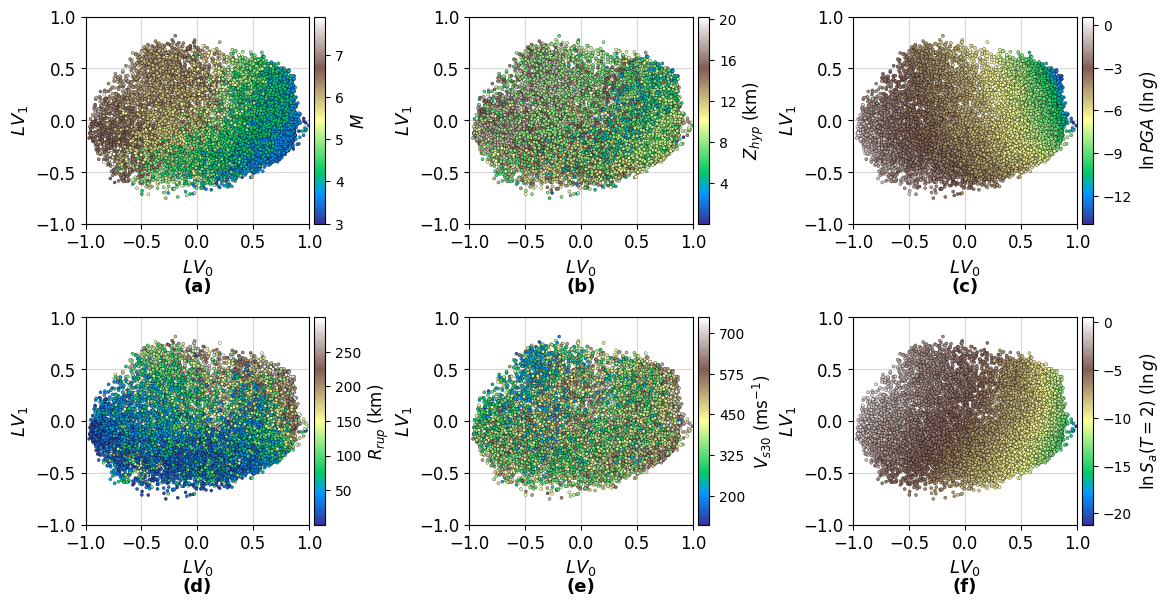

In [61]:
fig, ax = plt.subplots(2, 3, figsize=(13, 6.6))
for a in ax:
    for ax_ in a:
        ax_.set_xlim(-1, 1); ax_.set_ylim(-1, 1)
        ax_.grid(zorder=0, alpha=0.5)
        ax_.set_xlabel(r'$LV_0$', fontsize=13)
        ax_.set_ylabel(r'$LV_1$', fontsize=13)
        ax_.tick_params(axis='both', labelsize=12)
fig.subplots_adjust(hspace=0.45, wspace=0.6)

ax[0][0].scatter(z[:, 0], z[:, 1], s=5, c=data['Earthquake Magnitude'], zorder=2, edgecolor='black', linewidth=0.2)
ax[1][0].scatter(z[:, 0], z[:, 1], s=5, c=data['ClstD (km)'], zorder=2, edgecolor='black', linewidth=0.2)
ax[0][1].scatter(z[:, 0], z[:, 1], s=5, c=data['Hypocenter Depth (km)'], zorder=2, edgecolor='black', linewidth=0.2)
ax[1][1].scatter(z[:, 0], z[:, 1], s=5, c=data['Vs30 (m/s) selected for analysis'], zorder=2, edgecolor='black', linewidth=0.2)
ax[0][2].scatter(z[:, 0], z[:, 1], s=5, c=spectrum['PGA (g)'], zorder=2, edgecolor='black', linewidth=0.2)
ax[1][2].scatter(z[:, 0], z[:, 1], s=5, c=spectrum['T2.00S'], zorder=2, edgecolor='black', linewidth=0.2)

add_cbar(ax[0][0], data['Earthquake Magnitude'], r'$M$')
add_cbar(ax[0][1], data['Hypocenter Depth (km)'], r'$Z_{hyp}$ (km)', ticks=[4, 8, 12, 16, 20])
add_cbar(ax[1][0], data['ClstD (km)'], r'$R_{rup}$ (km)')
add_cbar(ax[1][1], data['Vs30 (m/s) selected for analysis'], r'$V_{s30}$ (ms$^{-1}$)', ticks=[200, 325, 450, 575, 700])
add_cbar(ax[0][2], spectrum['PGA (g)'], r'$\ln{PGA}$ ($\ln{g}$)', ticks=[-12.0, -9.0, -6.0, -3.0, 0.0])
add_cbar(ax[1][2], spectrum['T2.00S'], r'$\ln{S_a(T=2)}$ ($\ln{g}$)', ticks=[-20.0, -15.0, -10.0, -5.0, -0.0])

add_letter_label(ax[0][0], '(a)', [0.5, -0.3], 13)
add_letter_label(ax[0][1], '(b)', [0.5, -0.3], 13)
add_letter_label(ax[0][2], '(c)', [0.5, -0.3], 13)
add_letter_label(ax[1][0], '(d)', [0.5, -0.3], 13)
add_letter_label(ax[1][1], '(e)', [0.5, -0.3], 13)
add_letter_label(ax[1][2], '(f)', [0.5, -0.3], 13)

plt.savefig(f'{data_dir}/Latent Space {file_sfx}.png', bbox_inches='tight', dpi=400)

### Latent Space Groupings
This contains visualisation of the latent space embeddings of samples associated with two different groups (events).

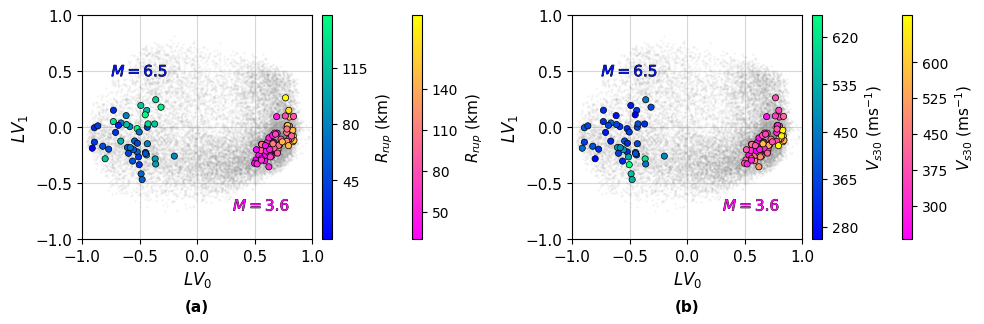

In [62]:
fig, ax = plt.subplots(1, 2, figsize=(10, 2.8))

# Chosen EQIDs to visualise samples off
sel_eqids = [309, 414]

# Background scatter plots
ax[0].scatter(z[:, 0], z[:, 1], s=1, color='grey', alpha=0.05, zorder=2)
ax[1].scatter(z[:, 0], z[:, 1], s=1, color='grey', alpha=0.05, zorder=2)

sc = []
for i, cmap, pos in zip(sel_eqids, ['spring', 'winter'], ["right", "right2"]):
    z_ = z[data['EQID'] == i]
    data_ = data[data['EQID'] == i]
    sc.append(ax[0].scatter(z_[:, 0], z_[:, 1], s=20, cmap=cmap, c=data_['ClstD (km)'], zorder=3, edgecolor='black', linewidth=0.5))
    sc.append(ax[1].scatter(z_[:, 0], z_[:, 1], s=20, cmap=cmap, c=data_['Vs30 (m/s) selected for analysis'], zorder=3, edgecolor='black', linewidth=0.5))

# Colourbars
ax[0].set_position([0.1, 0.15, 0.23, 0.8])
cbar_ax1 = fig.add_axes([0.34, 0.15, 0.01, 0.8])
cbar_ax2 = fig.add_axes([0.43, 0.15, 0.01, 0.8])
ax[1].set_position([0.59, 0.15, 0.23, 0.8])
cbar_ax3 = fig.add_axes([0.83, 0.15, 0.01, 0.8])
cbar_ax4 = fig.add_axes([0.92, 0.15, 0.01, 0.8])
cb = fig.colorbar(sc[2], cax=cbar_ax1, ticks=[45, 80, 115, 150, 185])
cb.set_label(r'$R_{rup}$ (km)', size=11)
cb = fig.colorbar(sc[0], cax=cbar_ax2, ticks=[20, 50, 80, 110, 140])
cb.set_label(r'$R_{rup}$ (km)', size=11)
cb = fig.colorbar(sc[3], cax=cbar_ax3, ticks=[280, 365, 450, 535, 620])
cb.set_label(r'$V_{s30}$ (ms$^{-1}$)', size=11)
cb = fig.colorbar(sc[1], cax=cbar_ax4, ticks=[300, 375, 450, 525, 600])
cb.set_label(r'$V_{s30}$ (ms$^{-1}$)', size=11)

for ax_ in ax:
    ax_.set_xlim(-1, 1); ax_.set_ylim(-1, 1)
    ax_.set_xticks([-1, -0.5, 0, 0.5, 1]); ax_.set_yticks([-1, -0.5, 0, 0.5, 1])
    ax_.grid(zorder=0, alpha=0.5)
    ax_.set_xlabel(r'$LV_0$', fontsize=12)
    ax_.set_ylabel(r'$LV_1$', fontsize=12)
    ax_.tick_params(axis='both', labelsize=11)

add_letter_label(ax[0], '(a)', pos=[0.5, -0.3])
add_letter_label(ax[1], '(b)', pos=[0.5, -0.3])
ax[0].text(0.78, 0.15, r'$M=$'+f'{data[data["EQID"] == sel_eqids[0]]["Earthquake Magnitude"].values[0]:.1f}', transform=ax[0].transAxes, ha='center', va='center', fontsize=11, color='#FF0DF2', 
           path_effects=[patheffects.withStroke(linewidth=0.5, foreground='black')])
ax[0].text(0.25, 0.75, r'$M=$'+f'{data[data["EQID"] == sel_eqids[1]]["Earthquake Magnitude"].values[0]:.1f}', transform=ax[0].transAxes, ha='center', va='center', fontsize=11, color='#0014F5', 
           path_effects=[patheffects.withStroke(linewidth=0.5, foreground='black')])
ax[1].text(0.78, 0.15, r'$M=$'+f'{data[data["EQID"] == sel_eqids[0]]["Earthquake Magnitude"].values[0]:.1f}', transform=ax[1].transAxes, ha='center', va='center', fontsize=11, color='#FF0DF2', 
           path_effects=[patheffects.withStroke(linewidth=0.5, foreground='black')])
ax[1].text(0.25, 0.75, r'$M=$'+f'{data[data["EQID"] == sel_eqids[1]]["Earthquake Magnitude"].values[0]:.1f}', transform=ax[1].transAxes, ha='center', va='center', fontsize=11, color='#0014F5', 
           path_effects=[patheffects.withStroke(linewidth=0.5, foreground='black')])

plt.savefig(f'{data_dir}/Group Embeddings {file_sfx}.png', bbox_inches='tight', dpi=400, transparent=True)

### Synthetic Spectra and Feature Estimation
This contains the generation of some synthetic response spectra with associated feature values estimated via a NN, trained here.

Training - Stage 1
99. Loss = 0.4418
Training - Stage 2
99. Loss = 0.5992


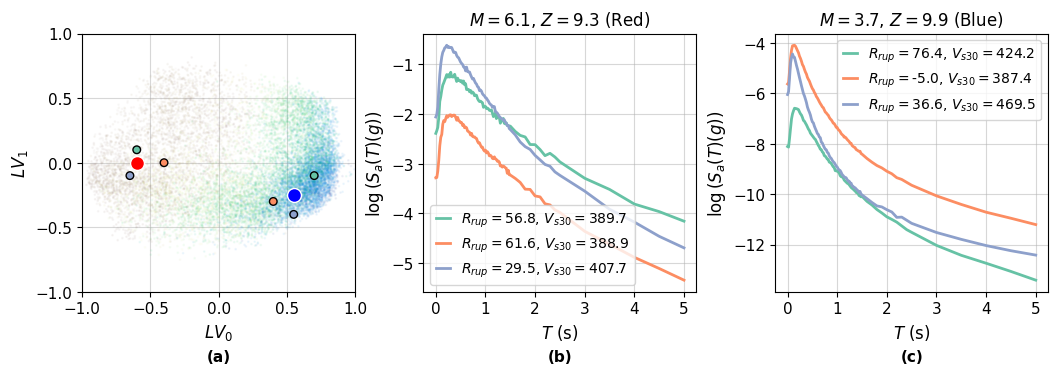

In [63]:
fig, ax = plt.subplots(1, 3, figsize=(10.5, 3.4))

# Adjust the axes to the right positions and add letter labels
ax[0].tick_params(axis='both', labelsize=11); ax[1].tick_params(axis='both', labelsize=11); ax[2].tick_params(axis='both', labelsize=11)
ax[0].set_position([0.06, 0.12, 0.26, 0.76])
ax[1].set_position([0.385, 0.12, 0.26, 0.76])
ax[2].set_position([0.72, 0.12, 0.26, 0.76])
add_letter_label(ax[0], '(a)', fontsize=11, pos=(0.5, -0.25))
add_letter_label(ax[1], '(b)', fontsize=11, pos=(0.5, -0.25))
add_letter_label(ax[2], '(c)', fontsize=11, pos=(0.5, -0.25))

# Create and train the NN
feat_pred = two_stage_nn(2, 2, 2, True, 1.0)
data.drop(columns=['err', 'res', 'bin mag', 'bin rup'], inplace=True)
feat_pred.train(z, data, ['Earthquake Magnitude', 'Hypocenter Depth (km)'], ['ClstD (km)', 'Vs30 (m/s) selected for analysis'], max_epochs_stage1=100, max_epochs_stage2=100)

# Defining the first centroid and points to visualise
event_centroid1 = [-0.6, 0.0]
samples1 = np.array([[-0.6, 0.1], [-0.4, 0.0], [-0.65, -0.1]])
synthetic_spectra = decoder(samples1).numpy()
feature_vals = feat_pred.predict(samples1, np.array([event_centroid1 for s in samples1]))

# Plotting the first spectra
colours = []
for s in range(samples1.shape[0]):
    p = ax[1].plot(T, synthetic_spectra[s], label=r'$R_{rup}=$'+f'{feature_vals[s, 2]:.1f}, '+r'$V_{s30}=$'+f'{feature_vals[s][3]:.1f}', linewidth=2)
    colours.append(p[0].get_color())
ax[1].grid(alpha=0.5, zorder=1)
ax[1].set_xlabel(r'$T$ (s)', fontsize=12)
ax[1].set_ylabel(r'$\log{(S_a(T) (g))}$', fontsize=12)
ax[1].set_title(r'$M=$'+f'{feature_vals[0, 0]:.1f}, '+r'$Z=$'+f'{feature_vals[0, 1]:.1f} (Red)', fontsize=12)
ax[1].legend(handlelength=1)
ax[1].set_xticks([0, 1, 2, 3, 4, 5])

# Defining the second centroid and points to visualise
event_centroid2 = [0.55, -0.25]
samples2 = np.array([[0.7, -0.1], [0.4, -0.3], [0.55, -0.4]])
synthetic_spectra = decoder(samples2).numpy()
feature_vals = feat_pred.predict(samples2, np.array([event_centroid2 for s in samples2]))

# Plotting the second spectra
for s in range(samples2.shape[0]):
    ax[2].plot(T, synthetic_spectra[s], label=r'$R_{rup}=$'+f'{feature_vals[s, 2]:.1f}, '+r'$V_{s30}=$'+f'{feature_vals[s][3]:.1f}', linewidth=2)
ax[2].grid(alpha=0.5, zorder=1)
ax[2].set_xlabel(r'$T$ (s)', fontsize=12)
ax[2].set_ylabel(r'$\log{(S_a(T) (g))}$', fontsize=12)
ax[2].set_title(r'$M=$'+f'{feature_vals[0, 0]:.1f}, '+r'$Z=$'+f'{feature_vals[0, 1]:.1f} (Blue)', fontsize=12)
ax[2].legend(handlelength=1)
ax[2].set_xticks([0, 1, 2, 3, 4, 5])

# Plotting the chosen points in the latent space
ax[0].scatter(z[:, 0], z[:, 1], s=1, c=data['Earthquake Magnitude'], alpha=0.05, zorder=2)
ax[0].scatter([event_centroid1[0]], [event_centroid1[1]], s=100, color='red', edgecolor='white', linewidth=1, zorder=3)
ax[0].scatter([event_centroid2[0]], [event_centroid2[1]], s=100, color='blue', edgecolor='white', linewidth=1, zorder=3)
ax[0].scatter(samples1[:, 0], samples1[:, 1], s=30, c=colours, edgecolor='black', linewidth=1, zorder=3)
ax[0].scatter(samples2[:, 0], samples2[:, 1], s=30, c=colours, edgecolor='black', linewidth=1, zorder=3)
ax[0].grid(alpha=0.5, zorder=1)
ax[0].set_xlim(-1, 1); ax[0].set_ylim(-1, 1)
ax[0].set_xticks([-1, -0.5, 0, 0.5, 1]); ax[0].set_yticks([-1, -0.5, 0, 0.5, 1])
ax[0].set_xlabel(r'$LV_0$', fontsize=12)
ax[0].set_ylabel(r'$LV_1$', fontsize=12)
    
plt.savefig(f'{data_dir}/Synthetic Samples {file_sfx}.png', bbox_inches='tight', dpi=400)

### Reconstructed Latent Space
This contains the latent embeddings colour-coded by the estimated feature values from the trained NN.

[0.8725965867674449, 0.15519350753290928, 0.2781290360984323, 0.1679603983655834]


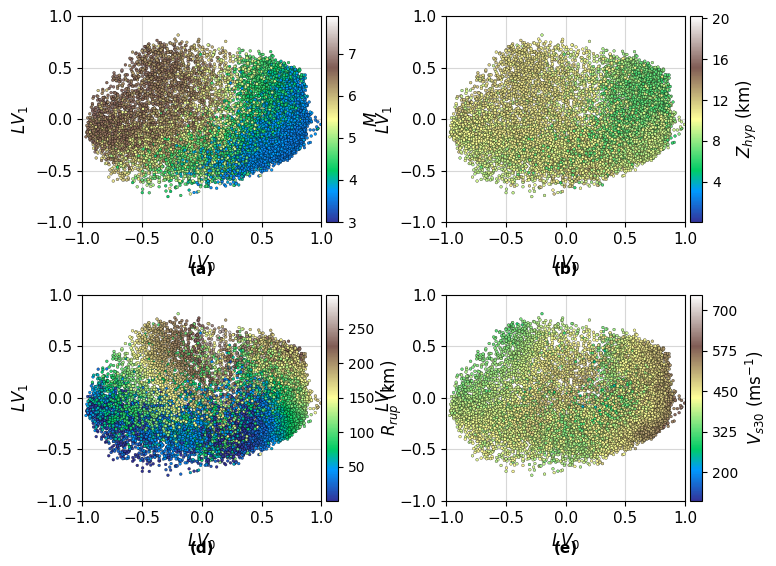

In [64]:
fig2, ax2 = plt.subplots(2, 2, figsize=(8, 6.3))
fig2.subplots_adjust(wspace=0.42, hspace=0.35)

# Evaluating on the entire dataset
z_, cent, trues, preds = feat_pred.evaluate(z, data, ['Earthquake Magnitude', 'Hypocenter Depth (km)'], ['ClstD (km)', 'Vs30 (m/s) selected for analysis'])
trues = trues.numpy()
    
ax2[0][0].scatter(z_[:, 0], z_[:, 1], c=preds[:, 0], vmin=trues[:, 0].min(), vmax=trues[:, 0].max(), s=4, edgecolor='black', linewidth=0.2, zorder=2)
ax2[0][1].scatter(z_[:, 0], z_[:, 1], c=preds[:, 1], vmin=trues[:, 1].min(), vmax=trues[:, 1].max(), s=4, edgecolor='black', linewidth=0.2, zorder=2)
ax2[1][0].scatter(z_[:, 0], z_[:, 1], c=preds[:, 2], vmin=trues[:, 2].min(), vmax=trues[:, 2].max(), s=4, edgecolor='black', linewidth=0.2, zorder=2)
ax2[1][1].scatter(z_[:, 0], z_[:, 1], c=preds[:, 3], vmin=trues[:, 3].min(), vmax=trues[:, 3].max(), s=4, edgecolor='black', linewidth=0.2, zorder=2)
add_cbar(ax2[0][0], trues[:, 0], r'$M$', ticks=[3, 4, 5, 6, 7])
add_cbar(ax2[0][1], trues[:, 1], r'$Z_{hyp}$ (km)', ticks=[4, 8, 12, 16, 20])
add_cbar(ax2[1][0], trues[:, 2], r'$R_{rup}$ (km)', ticks=[50, 100, 150, 200, 250])
add_cbar(ax2[1][1], trues[:, 3], r'$V_{s30}$ (ms$^{-1}$)', ticks=[200, 325, 450, 575, 700])
for a in ax2:
    for ax_ in a:
        ax_.grid(alpha=0.5, zorder=1)
        ax_.set_xlim(-1, 1)
        ax_.set_ylim(-1, 1)
        ax_.set_xlabel(r'$LV_0$', fontsize=12)
        ax_.set_ylabel(r'$LV_1$', fontsize=12)
        ax_.tick_params(axis='both', labelsize=11)
add_letter_label(ax2[0][0], '(a)', pos=[0.5, -0.23], fontsize=11)
add_letter_label(ax2[0][1], '(b)', pos=[0.5, -0.23], fontsize=11)
add_letter_label(ax2[1][0], '(d)', pos=[0.5, -0.23], fontsize=11)
add_letter_label(ax2[1][1], '(e)', pos=[0.5, -0.23], fontsize=11)

print([r2_score(trues[:, f], preds[:, f]) for f in range(preds.shape[1])])

plt.savefig(f'{data_dir}/Two-stage NN {file_sfx}.png', bbox_inches='tight', dpi=400)

### EEWS FFNN
This contains preparation of the data, training, and validation of the FFNN as a demonstration of applications within EEWS.

In [65]:
# Reading and preparing data ---
data.rename(columns={'Record Sequence Number':'RSN'}, inplace=True)
data['RSN'] = data['RSN'].astype(int)

IMs = pd.read_csv(IM_first3secs_data_filepath)
IMs['RSN'] = IMs['RSN'].astype(int)
ffnn_feats = ['Ia', 'CAV', 'PGV', 'PGA', 'PGD', 'Tm', 'D595']
ffnn_data = pd.merge(data, IMs[['RSN', *ffnn_feats]], on='RSN', how='left')

# Predicting z from X
z_ = z[ffnn_data['Ia'].isna().to_numpy() == False]
X = ffnn_data.loc[ffnn_data['Ia'].isna().to_numpy() == False, ffnn_feats].to_numpy()

499: 0.3500
All data: LV0 0.9470894254403833, LV1 0.6476565347075183
Training: LV0 0.9547577561737555, LV1 0.7157480923669488
Testing: LV0 0.9178393025987719, LV1 0.38482785571275124


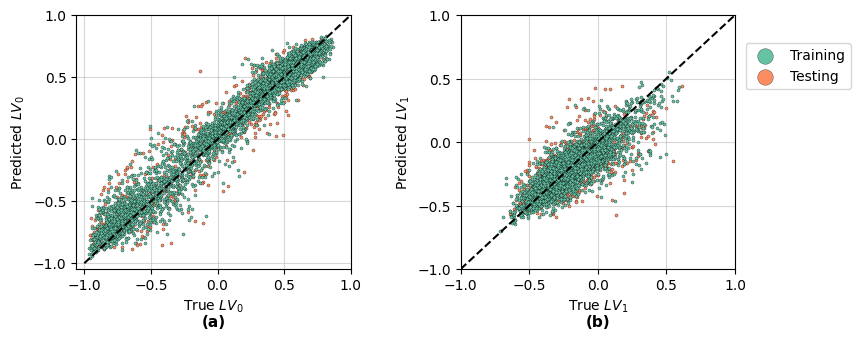

In [66]:
ffnn_model = ffnn(X.shape[1], z_.shape[1])
indices = np.arange(X.shape[0]); np.random.shuffle(indices)
train_indices, test_indices = indices[:int(0.8*X.shape[0])], indices[int(0.8*X.shape[0]):]
loss = ffnn_model.train(X[train_indices], z_[train_indices], 100, 500)
z_pred = ffnn_model.predict(X).numpy()

fig, ax = plt.subplots(1, 2, figsize=(8.5, 3.3))
fig.subplots_adjust(wspace=0.4)
ax[0].scatter(z_[train_indices, 0], z_pred[train_indices, 0], edgecolor='black', linewidth=0.2, s=5, zorder=3, label='Training')
ax[0].scatter(z_[test_indices, 0], z_pred[test_indices, 0], edgecolor='black', linewidth=0.2, s=5, zorder=2, label='Testing')
xlim, ylim = ax[0].get_xlim(), ax[0].get_ylim()
ax[0].plot([-1, 1], [-1, 1], linestyle='dashed', color='black', zorder=3)
ax[0].set_xlim(xlim); ax[0].set_ylim(ylim)
ax[0].grid(alpha=0.5, zorder=1)
ax[1].scatter(z_[train_indices, 1], z_pred[train_indices, 1], edgecolor='black', linewidth=0.2, s=5, zorder=3, label='Training')
ax[1].scatter(z_[test_indices, 1], z_pred[test_indices, 1], edgecolor='black', linewidth=0.2, s=5, zorder=2, label='Testing')
xlim, ylim = ax[1].get_xlim(), ax[1].get_ylim()
ax[1].plot([-1, 1], [-1, 1], linestyle='dashed', color='black', zorder=3)
ax[1].set_xlim(xlim); ax[1].set_ylim(ylim)
ax[1].grid(alpha=0.5, zorder=1)
ax[1].legend(loc='center', bbox_to_anchor=(1.23, 0.8), markerscale=5, fontsize=10)

ax[0].set_xlabel(r'True $LV_0$'); ax[0].set_ylabel(r'Predicted $LV_0$')
ax[1].set_xlabel(r'True $LV_1$'); ax[1].set_ylabel(r'Predicted $LV_1$')
ax[0].set_xticks([-1, -0.5, 0, 0.5, 1]); ax[0].set_yticks([-1, -0.5, 0, 0.5, 1])
ax[1].set_xticks([-1, -0.5, 0, 0.5, 1]); ax[1].set_yticks([-1, -0.5, 0, 0.5, 1])
ax[0].text(0.5, -0.21, '(a)', transform=ax[0].transAxes, ha='center', va='center', fontsize=11, fontweight='bold')
ax[1].text(0.5, -0.21, '(b)', transform=ax[1].transAxes, ha='center', va='center', fontsize=11, fontweight='bold')

print(f'All data: LV0 {r2_score(z_[:, 0], z_pred[:, 0])}, LV1 {r2_score(z_[:, 1], z_pred[:, 1])}')
print(f'Training: LV0 {r2_score(z_[train_indices, 0], z_pred[train_indices, 0])}, LV1 {r2_score(z_[train_indices, 1], z_pred[train_indices, 1])}')
print(f'Testing: LV0 {r2_score(z_[test_indices, 0], z_pred[test_indices, 0])}, LV1 {r2_score(z_[test_indices, 1], z_pred[test_indices, 1])}')
plt.savefig(f'{data_dir}/FFNN Residuals {file_sfx}.png', bbox_inches='tight', dpi=400)